<a href="https://colab.research.google.com/github/NupoorRaut/Deep-Learning/blob/main/05_TransferLearning_Cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf


from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Models
from tensorflow.keras.applications import (
    ResNet50, ResNet101, ResNet152,
    MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large,
    InceptionV3, InceptionResNetV2
)

# Preprocessing
from tensorflow.keras.applications.resnet import preprocess_input as resnet_pre
from tensorflow.keras.applications.mobilenet import preprocess_input as mob_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob2_pre
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mob3_pre
from tensorflow.keras.applications.inception_v3 import preprocess_input as inc_pre
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input as incres_pre

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kshitij192/cars-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cars-image-dataset' dataset.
Path to dataset files: /kaggle/input/cars-image-dataset


In [3]:
train_dir = "/kaggle/input/cars-image-dataset/Cars Dataset/train"
test_dir  = "/kaggle/input/cars-image-dataset/Cars Dataset/test"

img_size = (224,224)
batch_size = 32

In [15]:
models_dict = {
    "ResNet50": (ResNet50, resnet_pre),
    "ResNet101": (ResNet101, resnet_pre),
    "ResNet152": (ResNet152, resnet_pre),

    "MobileNet": (MobileNet, mob_pre),
    "MobileNetV2": (MobileNetV2, mob2_pre),
    "MobileNetV3Small": (MobileNetV3Small, mob3_pre),
    "MobileNetV3Large": (MobileNetV3Large, mob3_pre),

    "InceptionV3": (InceptionV3, inc_pre),
    "InceptionResNetV2": (InceptionResNetV2, incres_pre)
}

In [13]:
model_configs_phase_A = {
    "ResNet50": {'dense_units': 256, 'optimizer_lr': 0.001},
    "ResNet101": {'dense_units': 256, 'optimizer_lr': 0.001},
    "ResNet152": {'dense_units': 256, 'optimizer_lr': 0.001},
    "MobileNet": {'dense_units': 64, 'optimizer_lr': 0.001},
    "MobileNetV2": {'dense_units': 64, 'optimizer_lr': 0.001},
    "MobileNetV3Small": {'dense_units': 32, 'optimizer_lr': 0.001},
    "MobileNetV3Large": {'dense_units': 64, 'optimizer_lr': 0.001},
    "InceptionV3": {'dense_units': 128, 'optimizer_lr': 0.001},
    "InceptionResNetV2": {'dense_units': 128, 'optimizer_lr': 0.001}
}

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

save_dir = "/content/drive/MyDrive/Models"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [7]:
def get_generators(preprocess_func):

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_func,
        rotation_range=15,
        zoom_range=0.2,
        horizontal_flip=True
    )

    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_func)

    train_gen = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical'
    )

    test_gen = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224,224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    return train_gen, test_gen

In [8]:
def build_model(base_model_fn, num_classes, dense_units, lr):

    base = base_model_fn(weights='imagenet', include_top=False, input_shape=(224,224,3))

    for layer in base.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(dense_units, activation='relu')(x)   # 🔥 FROM CONFIG
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(base.input, output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),  # 🔥 FROM CONFIG
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base

In [9]:
def compute_all_metrics(y_true, y_pred, y_proba, class_names):

    cm = confusion_matrix(y_true, y_pred)

    TP_list, TN_list, FP_list, FN_list = [], [], [], []

    for i in range(len(class_names)):
        TP = cm[i,i]
        FN = np.sum(cm[i,:]) - TP
        FP = np.sum(cm[:,i]) - TP
        TN = np.sum(cm) - (TP+FP+FN)

        TP_list.append(TP)
        TN_list.append(TN)
        FP_list.append(FP)
        FN_list.append(FN)

    TP, TN, FP, FN = map(np.mean, [TP_list, TN_list, FP_list, FN_list])

    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    specificity = TN/(TN+FP)
    fpr = FP/(FP+TN)
    fnr = FN/(FN+TP)
    error = (FP+FN)/(TP+TN+FP+FN)

    return precision, recall, f1, specificity, fpr, fnr, error

In [19]:
all_models_data = []   # 🔥 store everything for visualization
results = []

In [20]:
for name, (model_fn, preprocess_func) in models_dict.items():

    print(f"\n🚀 Training {name}")

    config = model_configs_phase_A[name]
    dense_units = config['dense_units']
    lr = config['optimizer_lr']

    train_gen, test_gen = get_generators(preprocess_func)
    class_names = list(train_gen.class_indices.keys())

    model, base = build_model(
        model_fn,
        num_classes=len(class_names),
        dense_units=dense_units,
        lr=lr
    )

    history = model.fit(train_gen, validation_data=test_gen, epochs=10)

    # ------------------------
    # Predictions
    # ------------------------
    y_proba = model.predict(test_gen)
    y_pred = np.argmax(y_proba, axis=1)
    y_true = test_gen.classes

    # ------------------------
    # Metrics
    # ------------------------
    precision, recall, f1, specificity, fpr, fnr, error = compute_all_metrics(
        y_true, y_pred, y_proba, class_names
    )

    acc = model.evaluate(test_gen, verbose=0)[1]

    # ------------------------
    # Save model
    # ------------------------
    model_path = os.path.join(save_dir, f"{name}.keras")
    model.save(model_path)

    # ------------------------
    # Store results (table)
    # ------------------------
    results.append({
        "Model": name,
        "Dense Units": dense_units,
        "Learning Rate": lr,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Specificity": specificity,
        "FPR": fpr,
        "FNR": fnr,
        "Error Rate": error
    })

    # ------------------------
    # 🔥 STORE DATA FOR VISUALIZATION
    # ------------------------
    all_models_data.append({
        "name": name,
        "history": history,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "class_names": class_names
    })


🚀 Training ResNet50
Found 3352 images belonging to 7 classes.
Found 813 images belonging to 7 classes.
Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 75s 602ms/step - accuracy: 0.5704 - loss: 1.2430 - val_accuracy: 0.8118 - val_loss: 0.5975
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 52s 495ms/step - accuracy: 0.7440 - loss: 0.7509 - val_accuracy: 0.8573 - val_loss: 0.4493
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 49s 464ms/step - accuracy: 0.7780 - loss: 0.6525 - val_accuracy: 0.8807 - val_loss: 0.3740
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 82s 461ms/step - accuracy: 0.8195 - loss: 0.5357 - val_accuracy: 0.9041 - val_loss: 0.3165
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 455ms/step - accuracy: 0.8350 - loss: 0.5018 - val_accuracy: 0.8868 - val_loss: 0.3097
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 47s 445ms/step - accuracy: 0.8613 - loss: 0.4244 - val_accuracy: 0.9262 - val_loss: 0.2517
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 442ms/step - accuracy: 0.8529 - loss: 0.4217 - val_accuracy: 0.917

In [26]:
models_dict = {
    "ResNet50": resnet_pre,
    "ResNet101": resnet_pre,
    "ResNet152": resnet_pre,

    "MobileNet": mob_pre,
    "MobileNetV2": mob2_pre,
    "MobileNetV3Small": mob3_pre,
    "MobileNetV3Large": mob3_pre,

    "InceptionV3": inc_pre,
    "InceptionResNetV2": incres_pre
}

In [29]:
def plot_all_metrics(y_true, y_pred, y_proba, history, class_names, title="Model"):

    plt.figure(figsize=(14,10))

    # Confusion Matrix
    plt.subplot(2,2,1)
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # ROC Curve
    plt.subplot(2,2,2)
    y_bin = label_binarize(y_true, classes=range(len(class_names)))

    for i in range(len(class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{class_names[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title("ROC Curve")
    plt.legend(fontsize=7)

    # Accuracy Curve
    plt.subplot(2,2,3)
    plt.plot(history.history['accuracy'], label='Train')
    plt.plot(history.history['val_accuracy'], label='Validation')
    plt.title("Accuracy vs Epoch")
    plt.legend()

    # Loss Curve
    plt.subplot(2,2,4)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("Loss vs Epoch")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


📊 Visualizing ResNet50


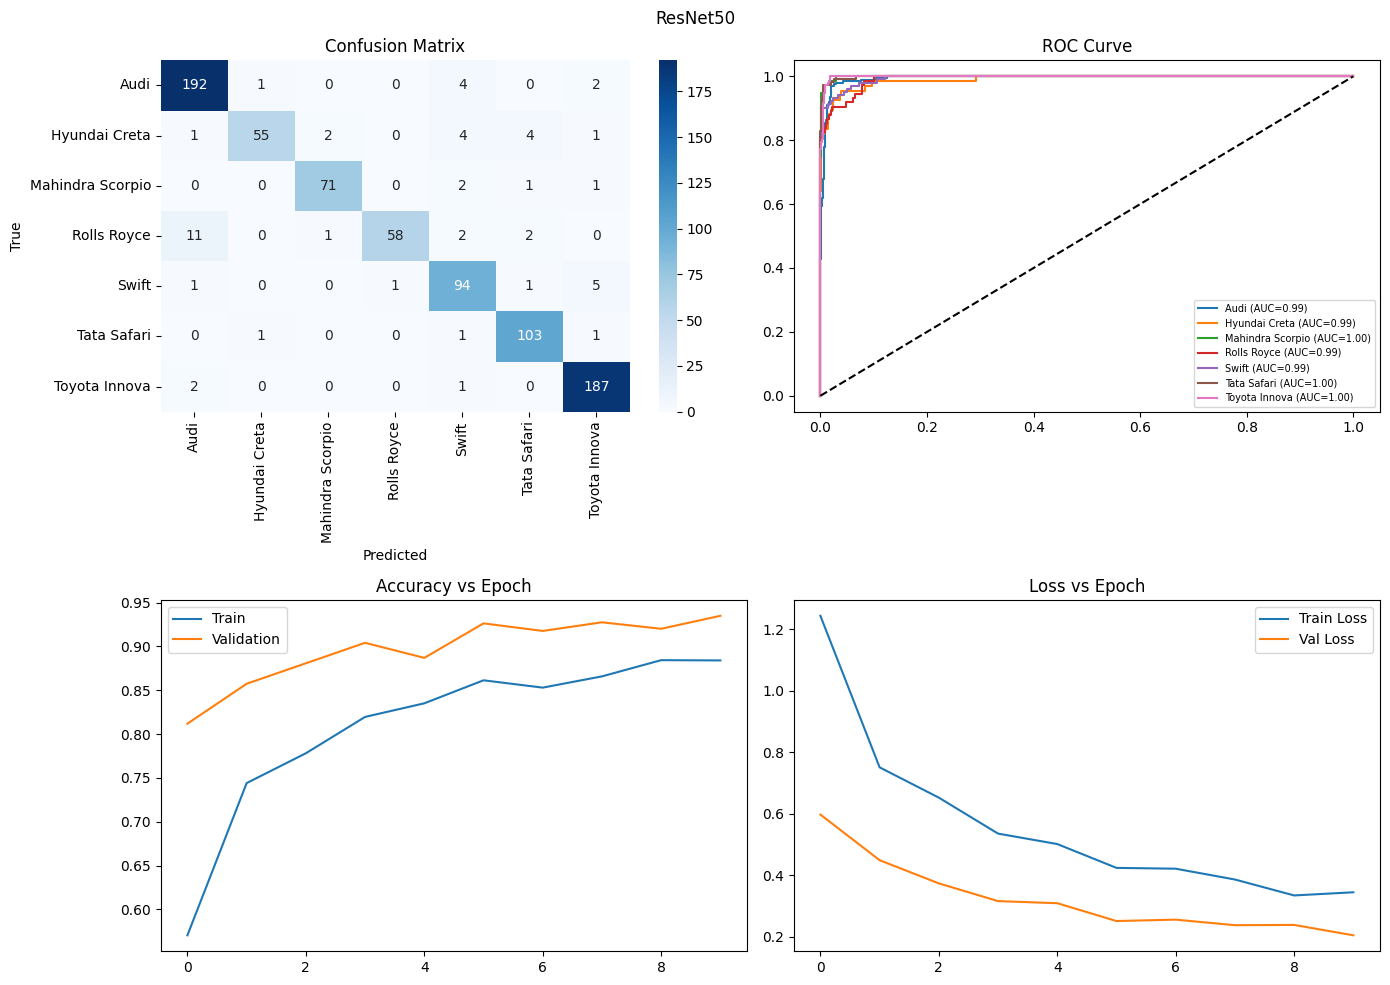


📊 Visualizing ResNet101


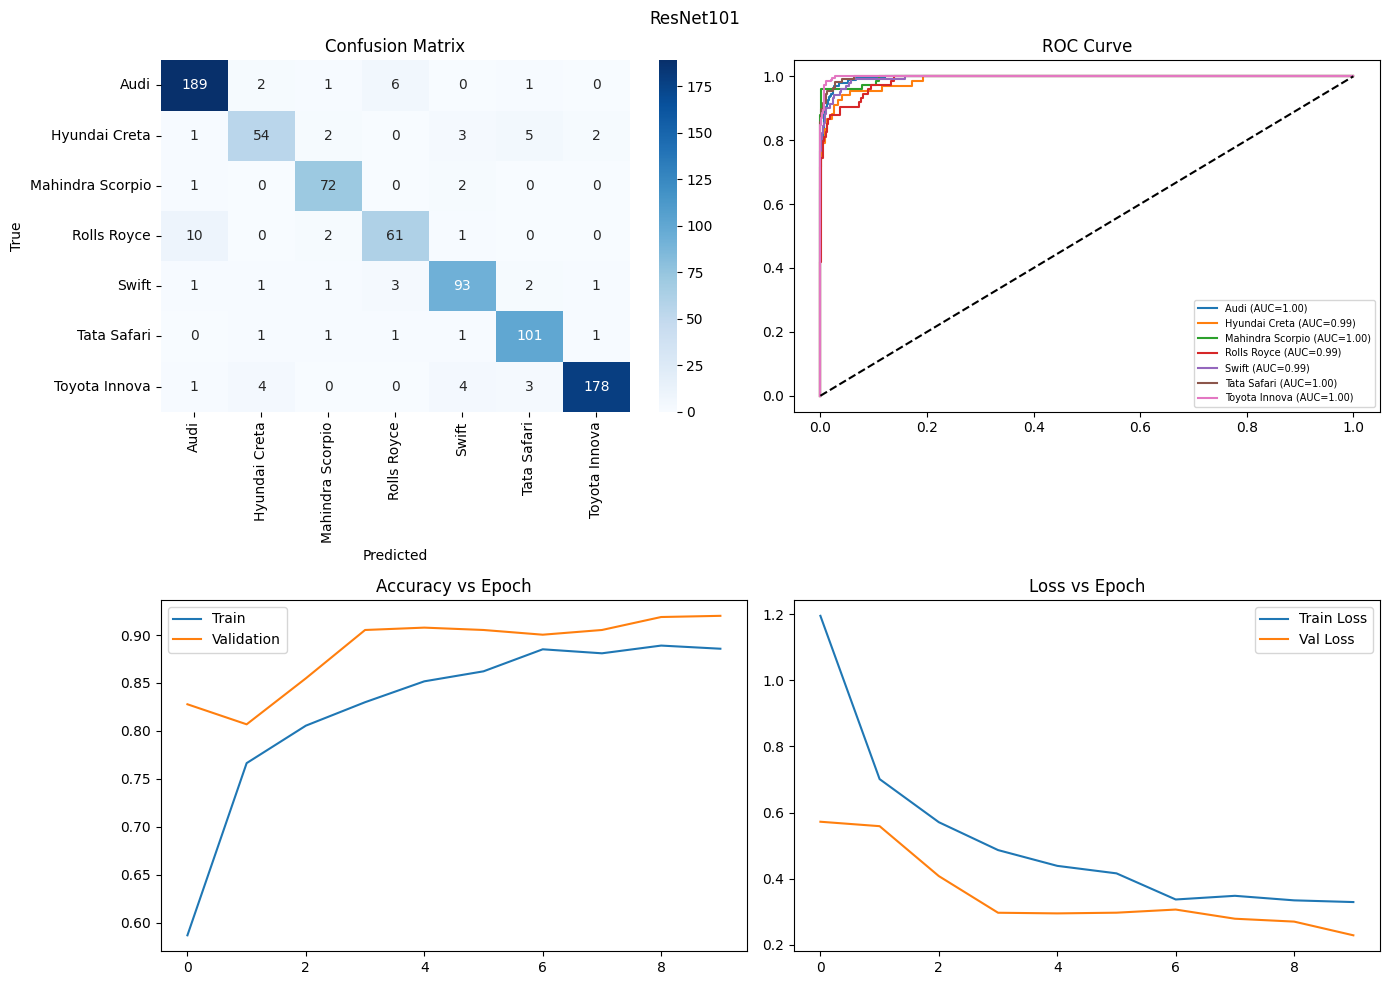


📊 Visualizing ResNet152


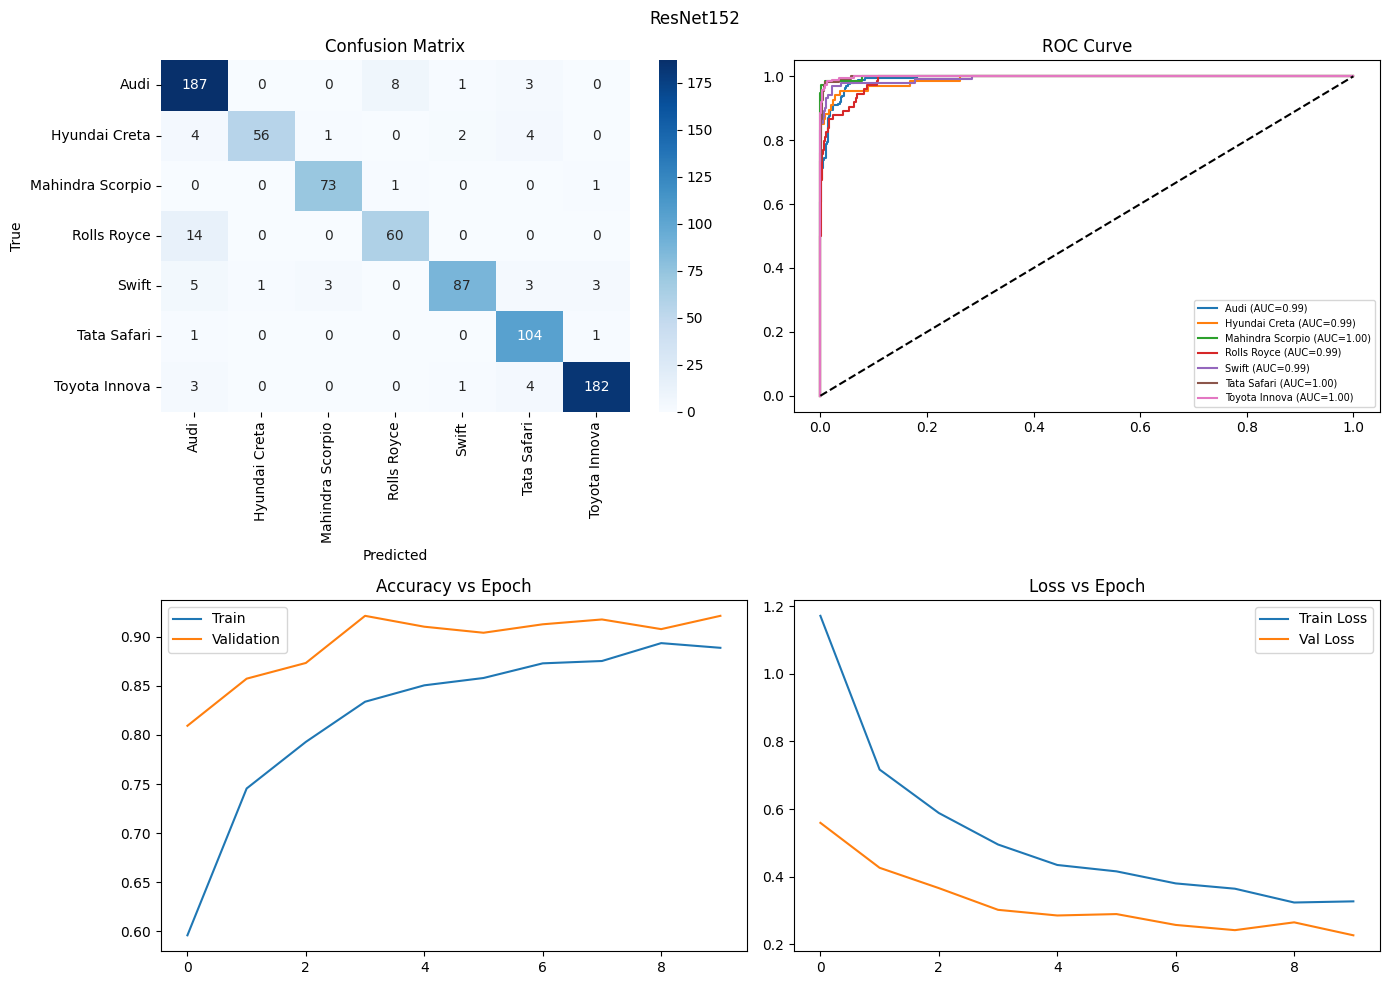


📊 Visualizing MobileNet


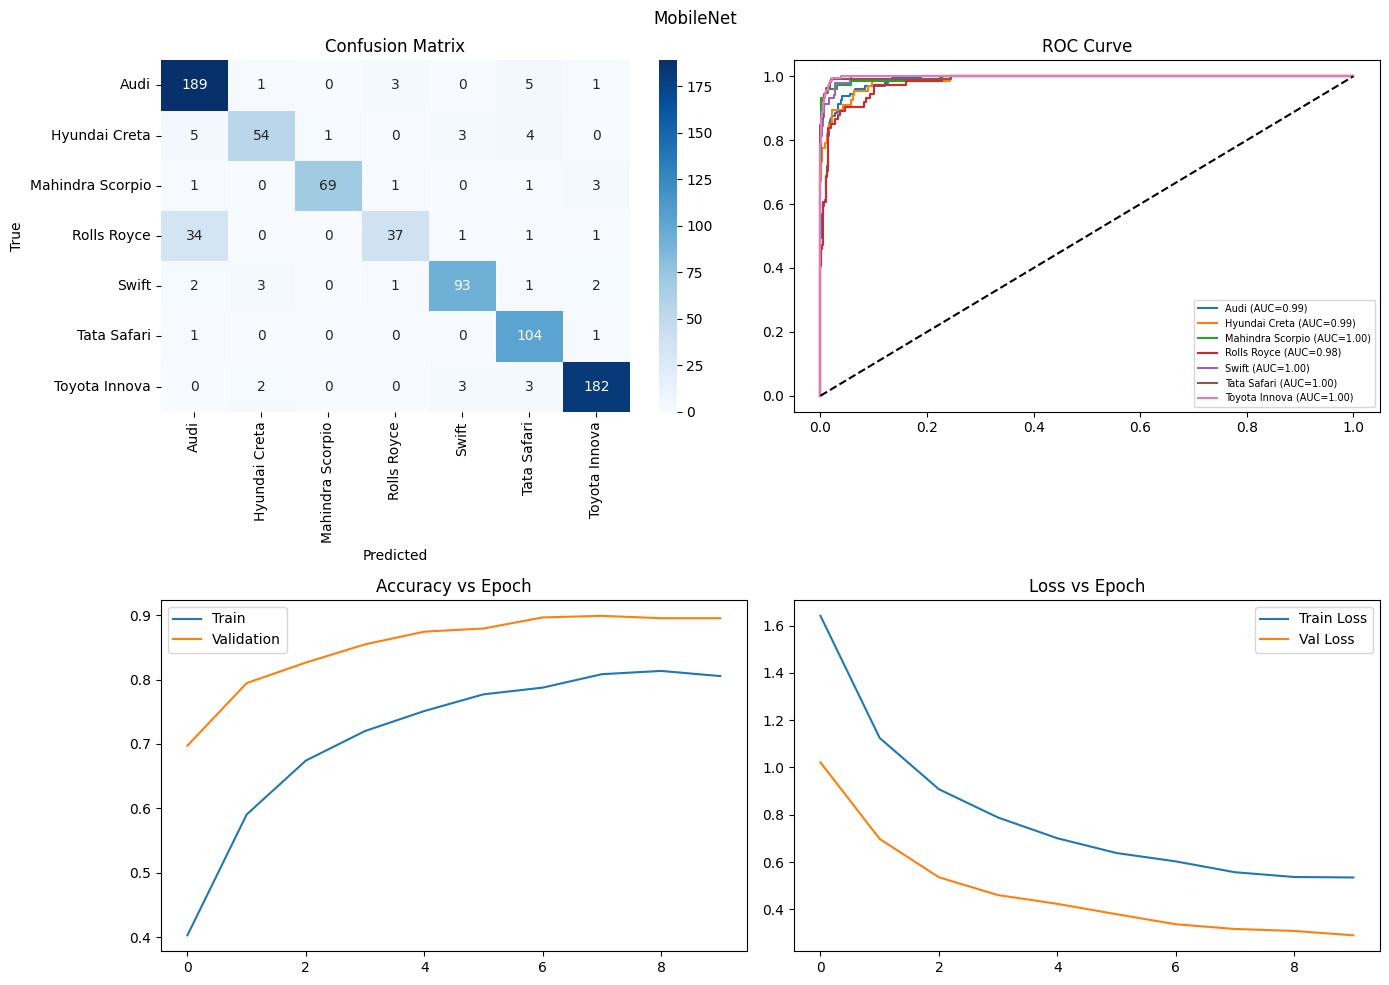


📊 Visualizing MobileNetV2


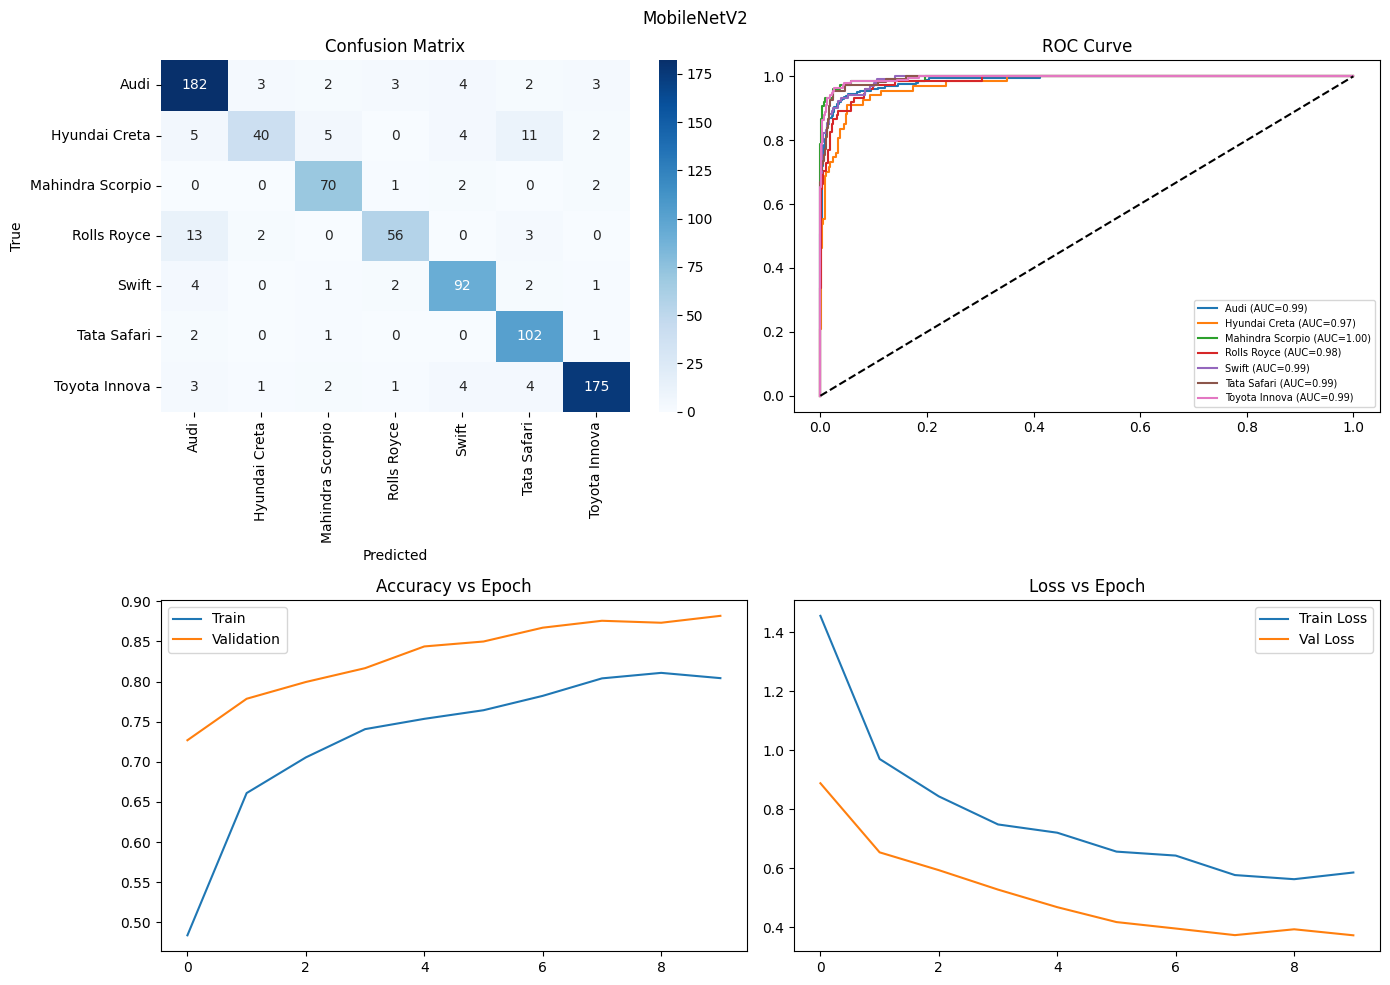


📊 Visualizing MobileNetV3Small


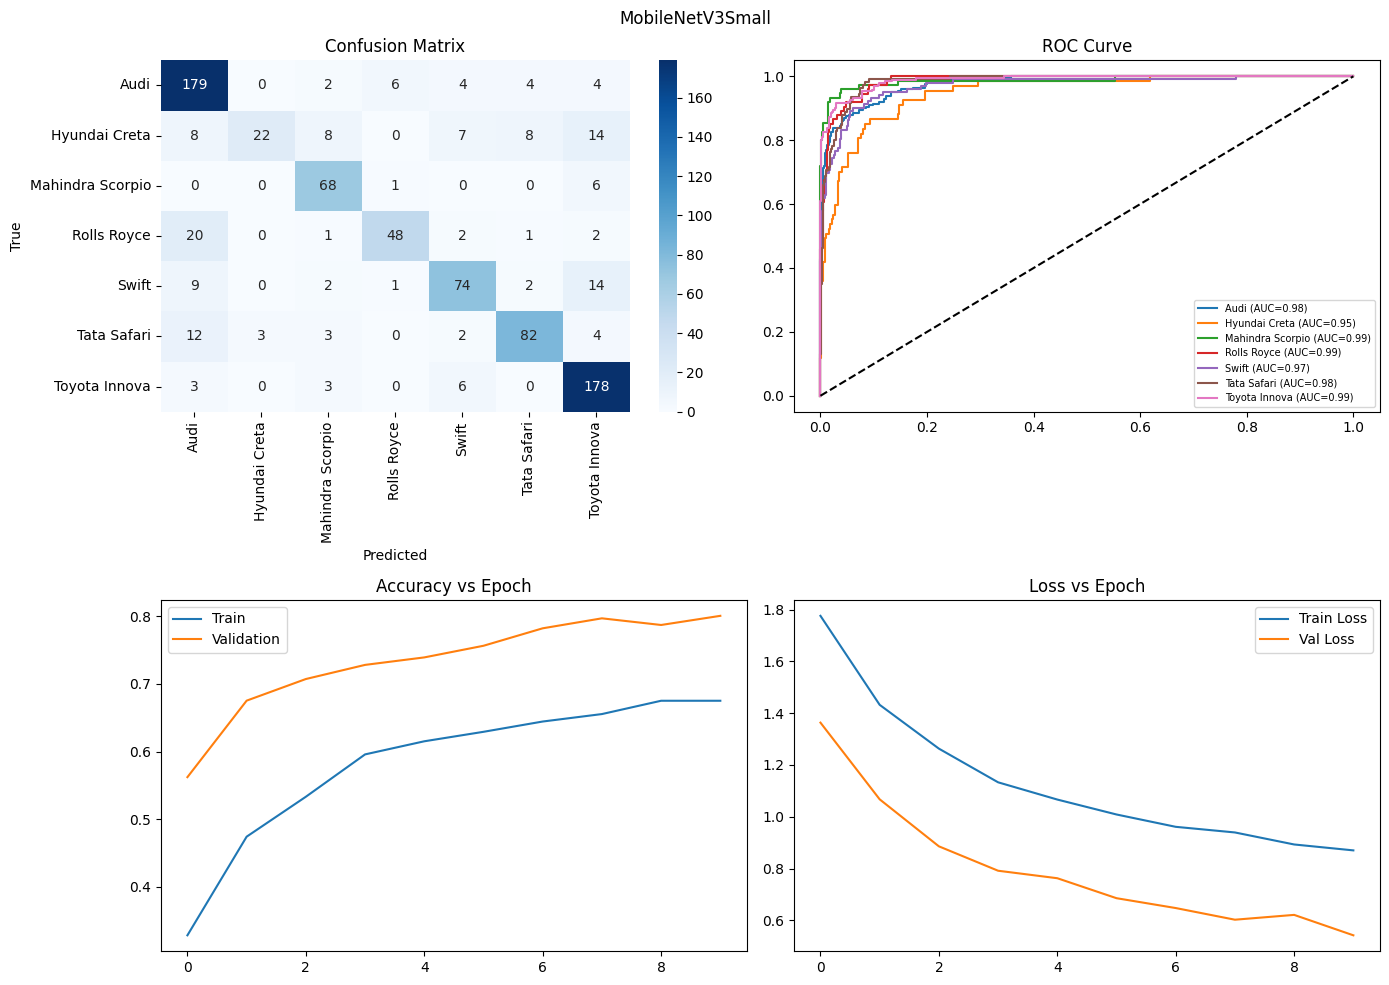


📊 Visualizing MobileNetV3Large


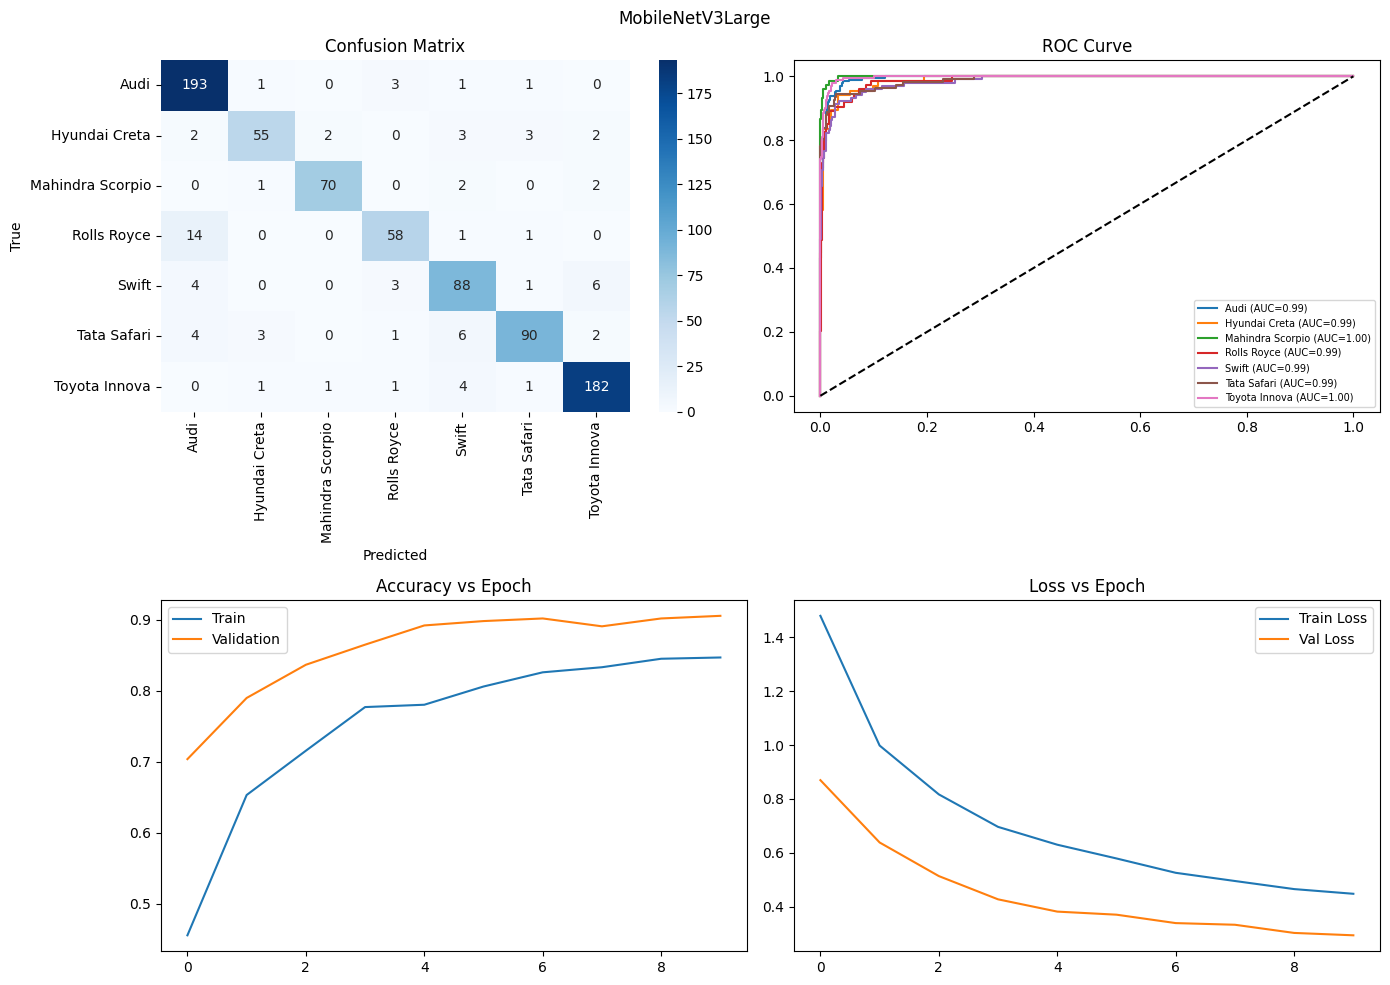


📊 Visualizing InceptionV3


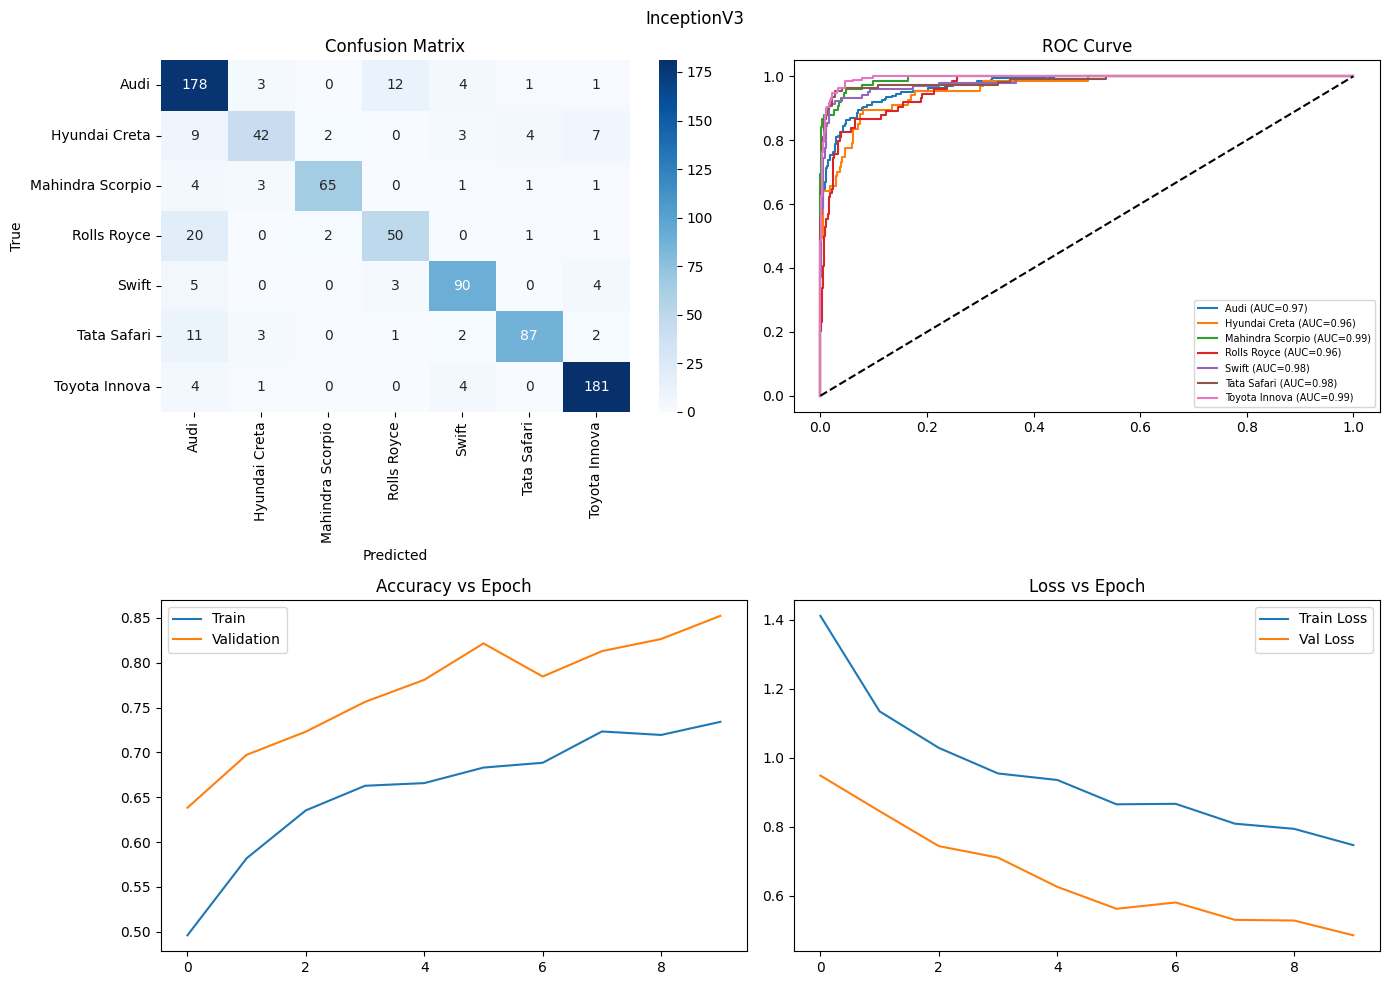


📊 Visualizing InceptionResNetV2


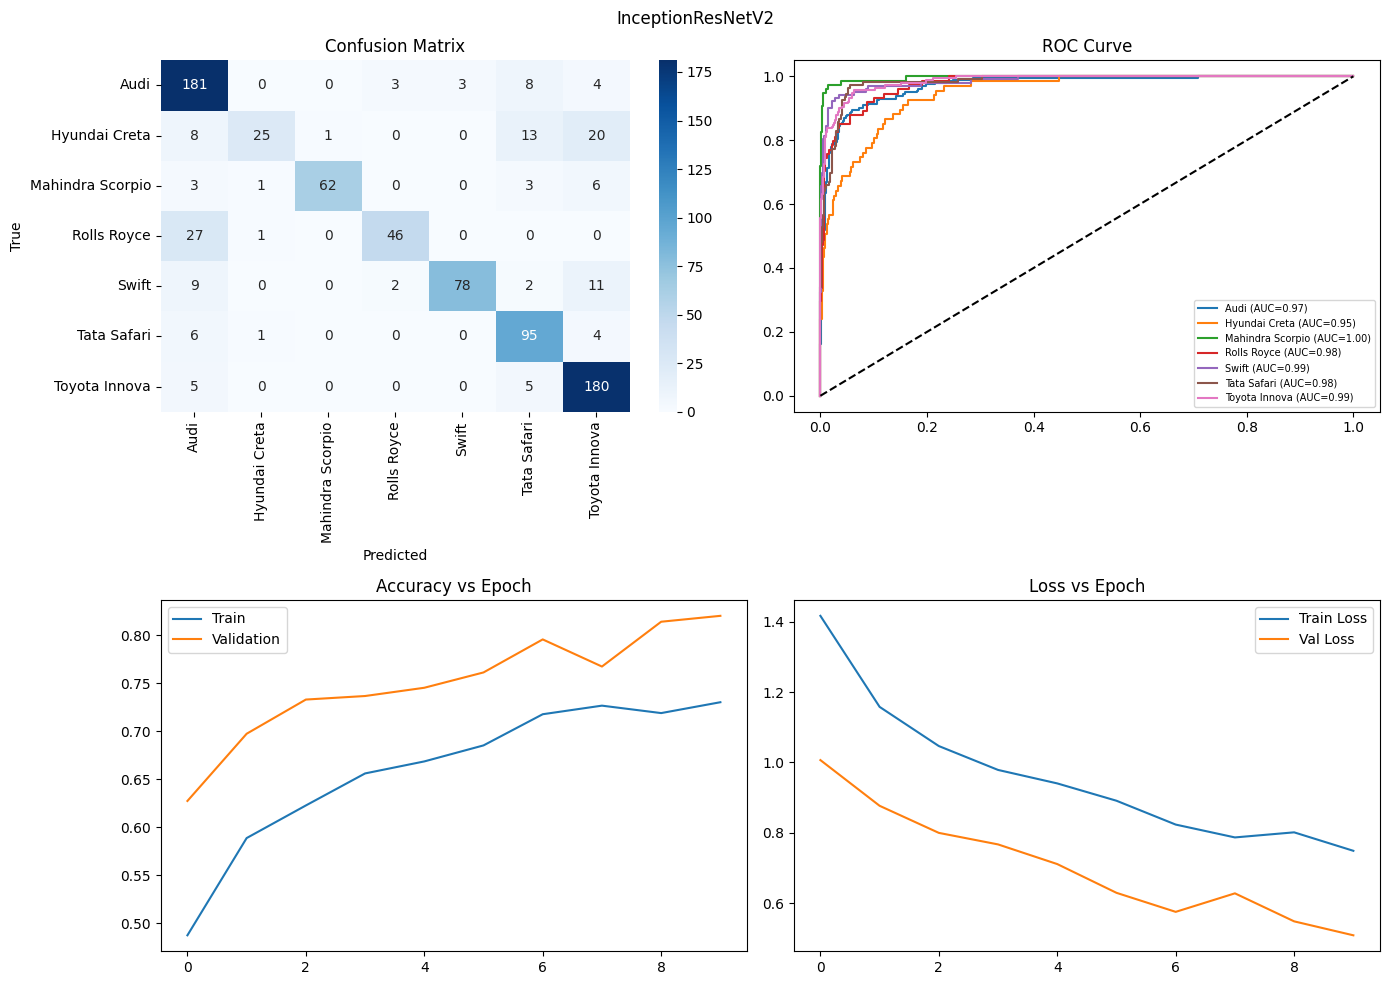

In [30]:
for data in all_models_data:

    print(f"\n📊 Visualizing {data['name']}")

    plot_all_metrics(
        data["y_true"],
        data["y_pred"],
        data["y_proba"],
        data["history"],
        data["class_names"],
        title=data["name"]
    )

In [34]:
df_results = pd.DataFrame(results)
df_results

,Model,Dense Units,Learning Rate,Accuracy,Precision,Recall,F1,Specificity,FPR,FNR,Error Rate
0,ResNet50,256,0.001,0.934809,0.936565,0.934809,0.933861,0.989135,0.010865,0.065191,0.018626
1,ResNet101,256,0.001,0.920049,0.920280,0.920049,0.919741,0.986675,0.013325,0.079951,0.022843
2,ResNet152,256,0.001,0.921279,0.923775,0.921279,0.920907,0.986880,0.013120,0.078721,0.022492
3,MobileNet,64,0.001,0.895449,0.899181,0.895449,0.890533,0.982575,0.017425,0.104551,0.029872
4,MobileNetV2,64,0.001,0.881919,0.883854,0.881919,0.879253,0.980320,0.019680,0.118081,0.033737
5,MobileNetV3Small,32,0.001,0.800738,0.807646,0.800738,0.789387,0.966790,0.033210,0.199262,0.056932
6,MobileNetV3Large,64,0.001,0.905289,0.905821,0.905289,0.904436,0.984215,0.015785,0.094711,0.027060
7,InceptionV3,128,0.001,0.852399,0.854999,0.852399,0.850782,0.975400,0.024600,0.147601,0.042172
8,InceptionResNetV2,128,0.001,0.820418,0.837916,0.820418,0.812016,0.970070,0.029930,0.179582,0.051309


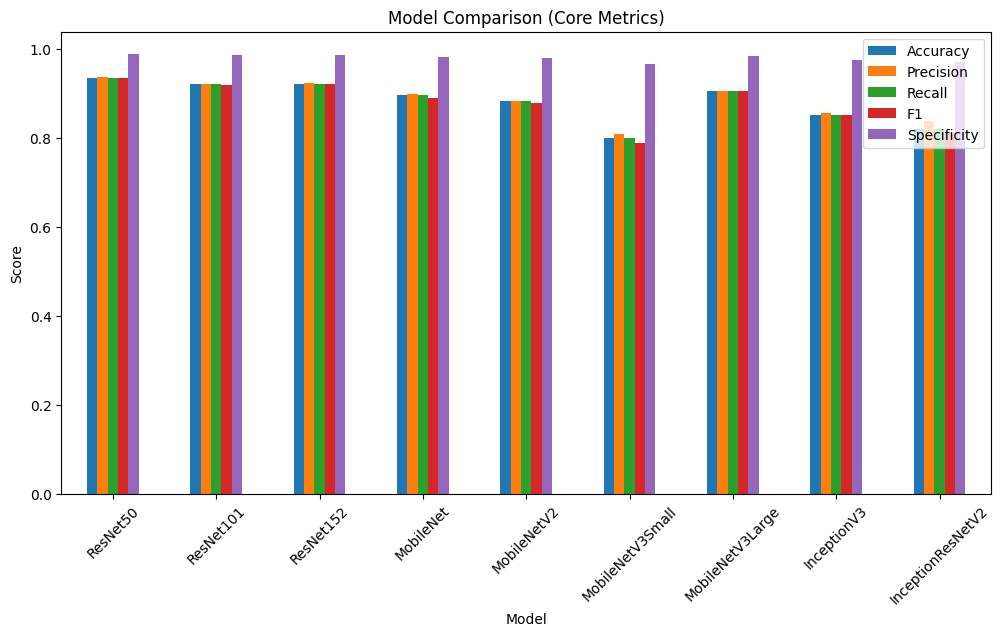

In [35]:
df_results.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1", "Specificity"
]].plot(kind='bar', figsize=(12,6))

plt.title("Model Comparison (Core Metrics)")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.show()

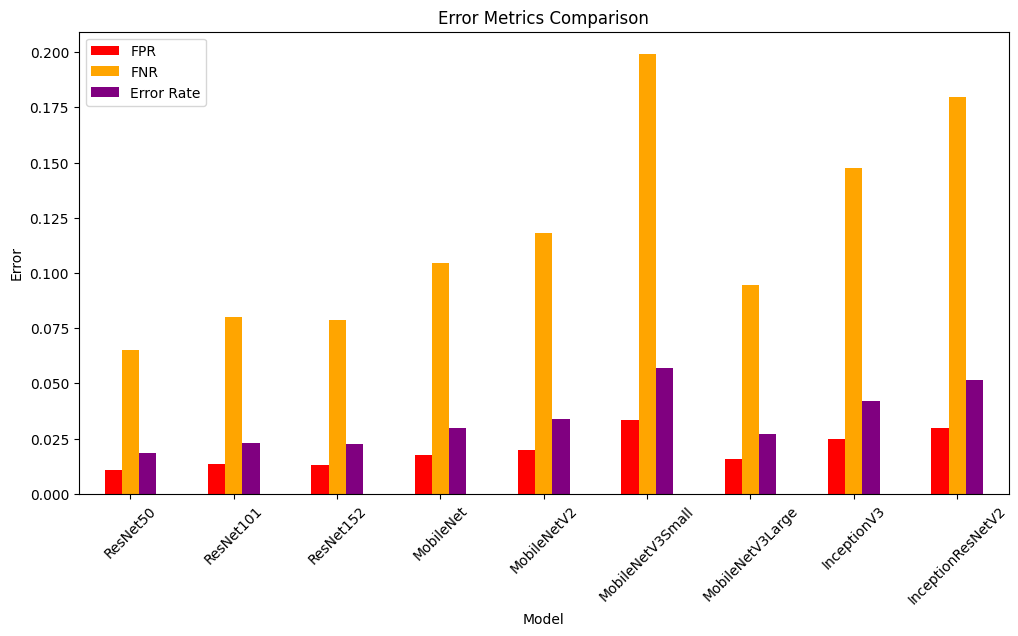

In [36]:
df_results.set_index("Model")[[
    "FPR", "FNR", "Error Rate"
]].plot(kind='bar', figsize=(12,6), color=['red','orange','purple'])

plt.title("Error Metrics Comparison")
plt.ylabel("Error")
plt.xticks(rotation=45)
plt.show()

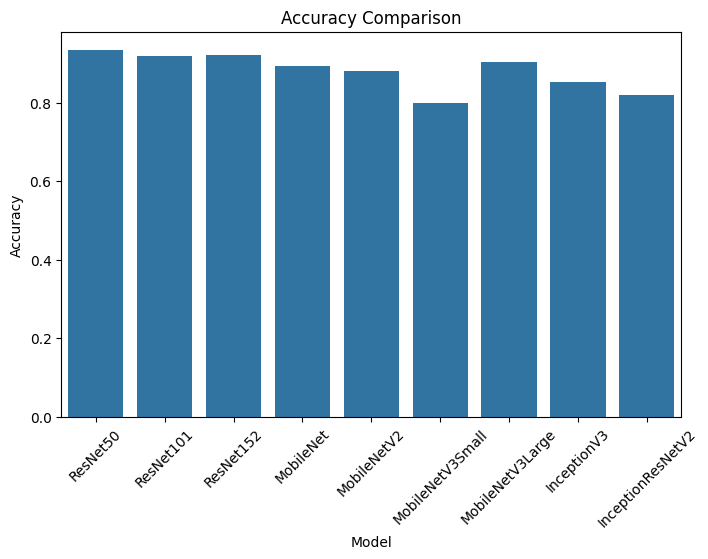

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=df_results)
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")
plt.show()

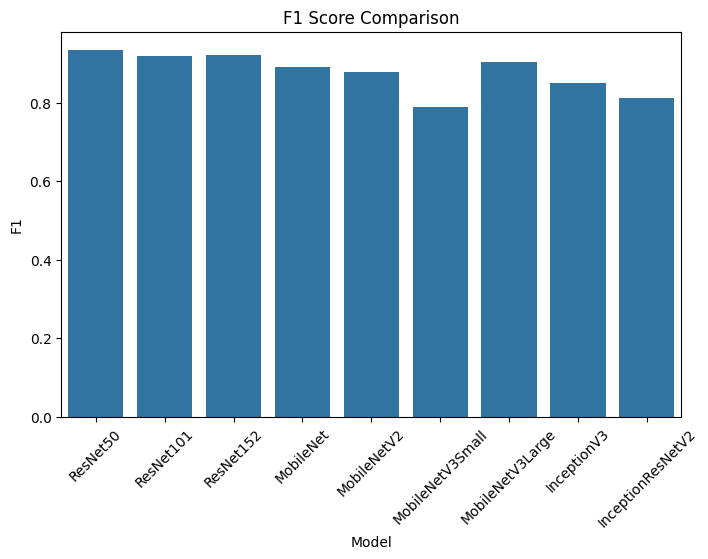

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="F1", data=df_results)
plt.xticks(rotation=45)
plt.title("F1 Score Comparison")
plt.show()

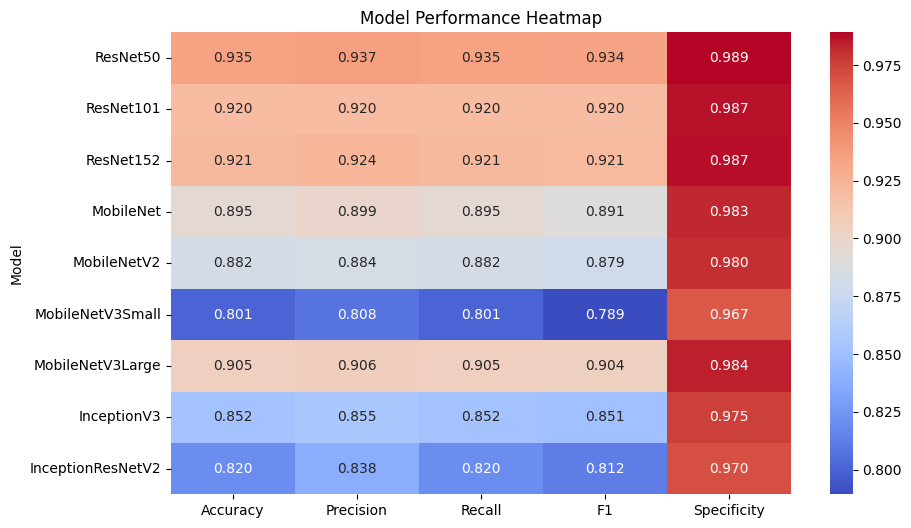

In [39]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df_results.set_index("Model")[[
        "Accuracy","Precision","Recall","F1","Specificity"
    ]],
    annot=True,
    cmap="coolwarm",
    fmt=".3f"
)

plt.title("Model Performance Heatmap")
plt.show()

In [40]:
best_model = df_results.sort_values(by="Accuracy", ascending=False).iloc[0]

print("🏆 Best Model:")
print(best_model)

🏆 Best Model:
Model            ResNet50
Dense Units           256
Learning Rate       0.001
Accuracy         0.934809
Precision        0.936565
Recall           0.934809
F1               0.933861
Specificity      0.989135
FPR              0.010865
FNR              0.065191
Error Rate       0.018626
Name: 0, dtype: object


📊 Overview

This experiment evaluates multiple deep learning architectures including ResNet (50/101/152), MobileNet variants, and Inception-based models using a fixed learning rate (0.001). The models were compared based on key performance metrics such as Accuracy, Precision, Recall, F1-score, Specificity, False Positive Rate (FPR), False Negative Rate (FNR), and Error Rate.


📈 Error Analysis

FPR (False Positive Rate):
Lowest in ResNet50 (0.0108)
Highest in MobileNetV3Small (0.0332)

FNR (False Negative Rate):
Lowest in ResNet50 (0.065)
Highest in MobileNetV3Small (0.199)

Error Rate:
Best: ResNet50 (0.0186)
Worst: MobileNetV3Small (0.0569)

👉 Indicates ResNet50 makes fewer wrong predictions

Key Observations
Precision, Recall, and F1-score are closely aligned → balanced models
Higher specificity (~0.98–0.99) across models → strong negative classification
Lightweight models show increased FNR → miss more true cases
Increasing model depth beyond ResNet50 gives diminishing returns

📌 Final Conclusion

Among all evaluated architectures, ResNet50 emerges as the most effective model, achieving the highest accuracy, lowest error rate, and best balance between precision and recall. While deeper networks like ResNet101 and ResNet152 increase model complexity, they do not significantly improve performance. Lightweight models such as MobileNet variants offer computational efficiency but at the cost of reduced accuracy and higher error rates.

Overall, the results highlight that model selection should balance accuracy and efficiency, and for this task, ResNet50 provides the optimal solution.